In [6]:
import json

import colorcet
import h5py
import matplotlib.pyplot as plt
import numpy as np

from lib.plots import set_axis
from lib.stats import fit_power_law

In [58]:
config_id = 300
filename = f"_outputs/output-{config_id}.h5"

with h5py.File(filename, "r") as store:
    config = json.loads(store["metadata/config_source"][()])
    config_used = json.loads(store["metadata/config"][()])

    production_overrides = config_used["sampling"]["phases"][-1]
    production_name = production_overrides["name"]
    phase_store = store["phases"][production_name]

    positions_history = []
    cohesins_history = {}

    for step_key in phase_store[".steps"]:
        sample = phase_store[step_key]

        positions = sample["positions"][:]
        positions_history.append(positions)

        for cohesin_id, (loaded_site, captured_site) in zip(
            sample["captures/ids"],
            sample["captures/sites"],
        ):
            if cohesin_id not in cohesins_history:
                cohesins_history[cohesin_id] = []
            if captured_site == loaded_site: # means non-capturing by convention
                captured_site = None
            cohesins_history[cohesin_id].append((loaded_site, captured_site))

    positions_history = np.array(positions_history)

In [59]:
sweep_data = config["@meta"]["sweep_data"]

max_width = max(len(key) for key in sweep_data.keys())
for key, value in sweep_data.items():
    print("{:{}s}  {:g}".format(key, max_width, value))

config_id                   300
chain_length                37
acetylation_level           0.108108
acetylation_capture_factor  5.17934
loading_constant            0.00558014
unloading_rate              0.000883156
capture_constant            0.316774
release_rate                0.00471814
crossing_factor             0.0959465
linear_diffusivity          1.73115


In [60]:
chain_used, = config_used["chains"]
chain_length = chain_used["length"]
default_valency = config_used["association"]["valency"]

selector_a = np.full(chain_length, False)
for feature in chain_used.get("association_features", []):
    is_a = False
    match feature:
        case {"valency": valency}:
            is_a = (valency < default_valency)

        case {"association": _} | {"dissociation": _}:
            assoc = feature.get("association", 1)
            dissoc = feature.get("dissociation", 1)
            is_a = (assoc < dissoc)

    if is_a:
        site = feature["site"]
        start = site["start"]
        end = site["end"]
        selector_a[start:end] = True

selector_b = ~selector_a

In [61]:
def drop_keys(d: dict, *arg: any) -> dict:
    return {key: value for key, value in d.items() if key not in arg}

In [62]:
sampling_config = config["sampling"]
production_config = {**drop_keys(sampling_config, "phases"), **production_overrides}

frame_interval = production_config["timestep"] * production_config["sampling_interval"]
diffusion_timescale = 1 / config["chain"]["monomer_mobility"]

In [63]:
def collect_msds(
    paths: np.ndarray,  # (time, particle, dim)
    lag: int,
) -> np.ndarray:
    squared_dists = np.zeros((lag, paths.shape[1]))
    for t in range(0, paths.shape[0] - lag):
        delta = paths[t:t + lag] - paths[t]
        squared_dists += (delta ** 2).sum(-1)
    return squared_dists / (paths.shape[0] - lag)


def subtract_centroid(paths: np.ndarray) -> np.ndarray:
    return paths - paths.mean(axis=1, keepdims=True)

In [64]:
lag_frames = 8
lag_time = lag_frames * frame_interval

#paths = subtract_centroid(positions_history)
paths = positions_history

msd = collect_msds(paths, lag=lag_frames).mean(1)

x = frame_interval * np.arange(len(msd))
y = msd
alpha, beta = fit_power_law(x, y)

if selector_a.sum() > 0:
    y = msd_a = collect_msds(paths[:, selector_a], lag=lag_frames).mean(1)
    alpha_a, beta_a = fit_power_law(x, y)

if selector_b.sum() > 0:
    y = msd_b = collect_msds(paths[:, selector_b], lag=lag_frames).mean(1)
    alpha_b, beta_b = fit_power_law(x, y)

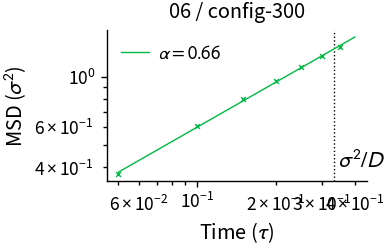

In [65]:
color = "C:g"

fig, ax = plt.subplots(figsize=(2.0, 1.3))

x = np.arange(len(msd)) * frame_interval
y = msd
ax.scatter(x, y, s=3, marker="x", color=color)

x = powerlaw_x = np.logspace(np.log10(frame_interval), np.log10(lag_time), num=100)
y = powerlaw_y = x**alpha * beta
s = r"$ \alpha = %.2f $" % alpha
ax.plot(x, y, color=color, label=s)

x = diffusion_timescale
y = powerlaw_y.min()
s = r" $ \sigma^2 / D $"
ax.text(x, y, s, ha="left", va="bottom")
ax.axvline(x, ls=":", zorder=1)

ax.set_xlabel(r"Time ($ \tau $)")
ax.set_ylabel(r"MSD ($ \sigma^2 $)")
ax.set_title(f"06 / config-{config_id}")
ax.legend()

ax.set_xscale("log")
ax.set_yscale("log")

set_axis(ax, "left bottom")

pass